Goal here is to see how we might do multigrid interp between levels for an isogeometric B-spline basis.
The tricky part is that the mid-side nodes are not exactly a node point.
Also in middle of plate, corner nodes of element are also not lagrange-lobatto-like and don't line up with node.
Is that right? Let's see by comparing basis functions between levels in 1D (maybe some simple non-PDE function with multigrid).

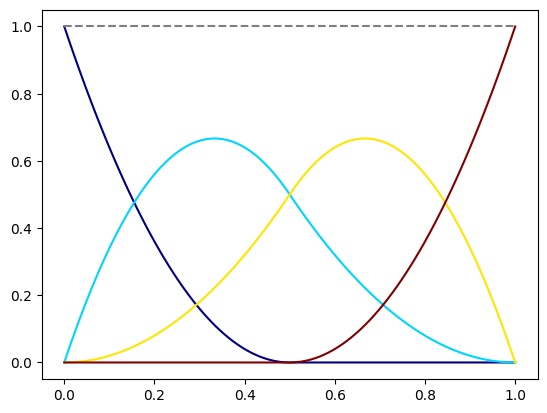

In [11]:
# first run with nxe = 2 elements (then we'll do four)
import matplotlib.pyplot as plt
import numpy as np

nxe, p = 2, 2
# nxe, p = 16, 2
nglob = nxe+p # number of global basis functions
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
u = np.linspace(0.0, 1.0, 100)
global_basis = np.zeros((nglob, u.shape[0]))
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on el;ement position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

coarse_basis = global_basis.copy()

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])

# and check the sum of each basis functions
SUM = np.sum(global_basis, axis=0)
plt.plot(u, SUM, '--', color="tab:gray")
# sum is 1!
plt.show()

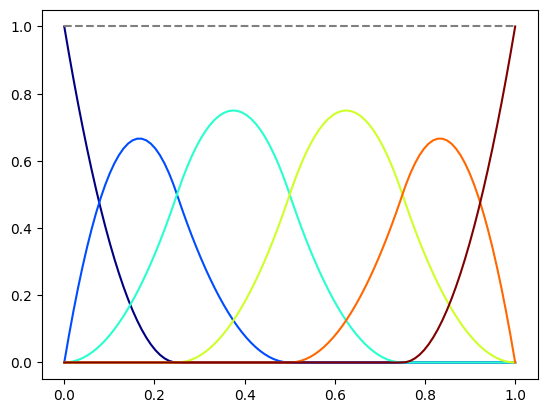

In [12]:
# then nxe = 4 elems

nxe, p = 4, 2
# nxe, p = 16, 2
nglob = nxe+p # number of global basis functions
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
u = np.linspace(0.0, 1.0, 100)
global_basis = np.zeros((nglob, u.shape[0]))
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on el;ement position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

fine_basis = global_basis.copy()

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])

# and check the sum of each basis functions
SUM = np.sum(global_basis, axis=0)
plt.plot(u, SUM, '--', color="tab:gray")
# sum is 1!
plt.show()

P_left_dof=array([[0.75, 0.25, 0.  ],
       [0.25, 0.75, 0.75],
       [0.  , 0.  , 0.25]])
x=array([0.25, 0.  , 0.  ])
P_right_basis=array([[ 2.50000000e-01,  0.00000000e+00,  0.00000000e+00],
       [ 7.50000000e-01,  7.50000000e-01,  2.50000000e-01],
       [-5.55111512e-17,  2.50000000e-01,  7.50000000e-01]])


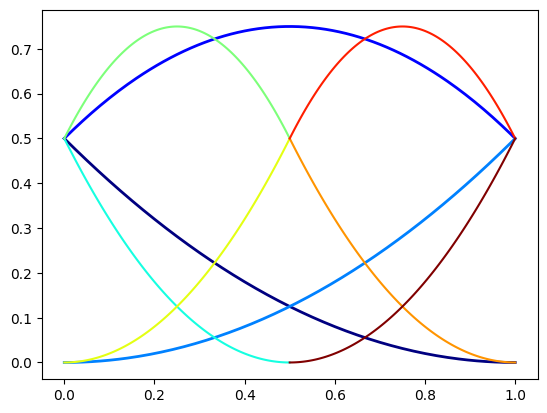

In [13]:
# basically need to do a local projection mapping from fine to coarse bases of KNOT INSERTION of b-spline basis
# may be even more accurate multigrid prolongation than standard lagrange bases..
# this is because prolongation is a geometric-style operator and high-order lagrange is not as great at smoothly modeling geometry..

# so in other words this could give MUCH BETTER MULTIGRID PERFORMANCE TOO (with high order) - cool!

# need to solve the basis functions coefficient interps at polynomial level (depending on interior vs bndry), etc.
# e.g. need to consider the 1st fine basis function spans half the coarse elem and we need it to be interpolated from 
# the three coarse basis functions (by solving 3x3 system, pre-computed and then we'll just assemble those coefficients)

# nxe_c, p = 2, 2
# nxe_f = 4
# 1 element each
p = 2
ncoarse = p+1
nfine = 2*ncoarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, nfine+ncoarse))

xi = np.linspace(0.0, 1.0, 201)
N_H = np.array([0.5 - xi + xi**2/2.0, 0.5 + xi - xi**2, xi**2/2.0])
# plot the coarse basis functions for an interior element
for i in range(3):
    plt.plot(xi, N_H[i], color=colors[i], linewidth=2.0)

# now compute first half-elem fine basis functions as interp from coarse basis
# coarse functions: on xi in [0, 1] 
#   N_H = [0.5-xi+xi^2/2,
#          0.5+xi-xi^2,
#          xi^2/2]
# fine functions (left) : global xi in [0,1] but left elem NZ in [0, 0.5] only
# conversion is xi_f = 2*xi
#   N_h = [0.5-2*xi+2*xi^2,
#          0.5+2*xi-4*xi^2,
#          2*xi^2]

# now expressing each N_H = P_left_basis * N_h gives us
P_left_basis = np.array([
    [1.5, -0.5, 1.5],
    [-0.5, 1.5, -4.5],
    [0.0, 0.0, 4.0]
])
N_Lh = np.dot(P_left_basis, N_H)

# basis value interp is inverse matrix of this
# as coarse function is liek f_H = u_H^T N_H
# and to get f_h = u_h^T N_h we need u_h = P_basis^{-1} * u_H
# f_h = u_h^T P_basis * N_H
# f_H = u_H * N_H => u_h = P_basis^{-1} * u_H
# or supposed to be the transposed inverse?

P_left_dof = np.linalg.inv(P_left_basis)
print(f"{P_left_dof=}")
# after solving it we got
P_left_dof = np.array([
    [0.75, 0.25, 0.0],
    [0.25, 0.75, 0.75],
    [0.0, 0.0, 0.25],
])

for i in range(3):
    plt.plot(xi[:101], N_Lh[i][:101], color=colors[i+3], linewidth=1.5)


# ===========================
# now for the right fine element..
# ===========================
# coarse functions: on xi in [0, 1] 
#   N_H = [0.5-xi+xi^2/2,
#          0.5+xi-xi^2,
#          xi^2/2]
# fine functions (left) : global xi in [0,1] but left elem NZ in [0.5, 1.0]
# conversion is xi_f = 2*xi-1 so that xi in [0.5, 1] equiv to xi_f in [0,1]
#   N_Rh = [0.5-xi_f+xi_f^2/2,  = [+2.0 - 4*xi + 2*xi^2,
#          0.5+xi_f-xi_f^2,       -1.5 + 6*xi - 4*xi^2,
#          xi_f^2/2]              +0.5 - 2*xi + 2*xi^2]

# first linear system
N_rh_poly = np.array([[2.0, -4.0, 2.0], [-1.5, 6.0, -4.0], [0.5, -2.0, 2.0]])
A = N_rh_poly.T
b = np.array([0.5, -1.0, 0.5])
x = np.linalg.solve(A, b)
print(f"{x=}")

# # now expressing as N_rh = P_right_basis * N_H
N_H_poly = np.array([[0.5, -1.0, 0.5], [0.5, 1.0, -1.0], [0.0, 0.0, 0.5]])
N_rh_poly = np.array([[2.0, -4.0, 2.0], [-1.5, 6.0, -4.0], [0.5, -2.0, 2.0]])
# transposed cause see x above recovered in first row like that
P_right_basis = np.linalg.solve(N_rh_poly.T, N_H_poly.T).T
print(f"{P_right_basis=}")
# ends up giving you: (pre-computed now on host)
P_right_basis = np.array([
    [0.25, 0.0, 0.0],
    [0.75, 0.75, 0.25],
    [0.0, 0.25, 0.75]
])

N_Rh = np.dot(np.linalg.inv(P_right_basis), N_H)
for i in range(3):
    plt.plot(xi[100:], N_Rh[i][100:], color=colors[i+6], linewidth=1.5)
plt.show()


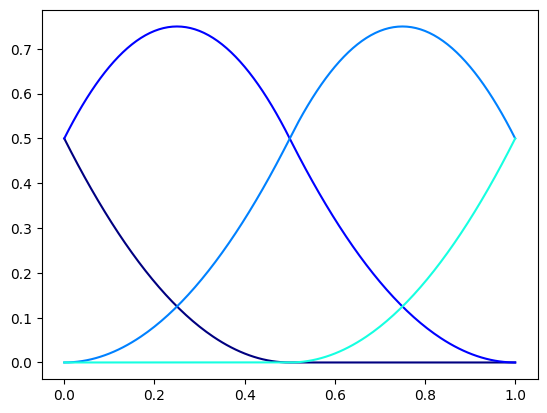

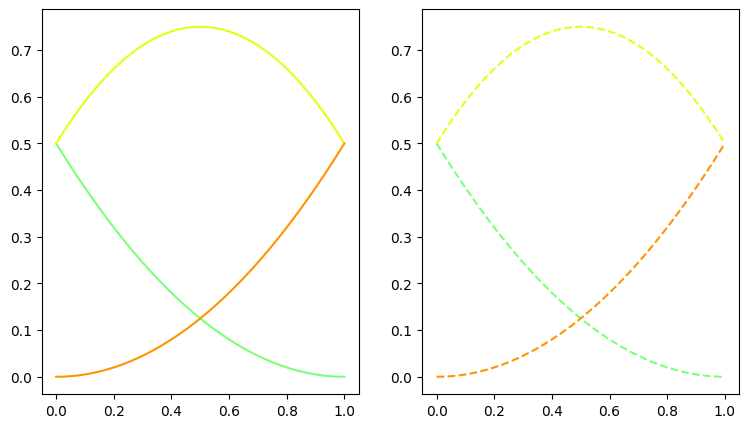

In [14]:

# but if I write it like N_H = P^T * N_h global
# which may not be exact, but they say that there is an exact solution, then we have an exact prolongation
# because u_h = P * u_H

# let's try and assemble the global P^T transformation (with in this case three coarse basis, four fine basis)
# the left and right sides are separte basis functions but two interior fine bases connect for four total fine basis
# I was concerned about the second basis function not matching, but I think even though it's piecewise constructed
# with fine basis functions 
PT = np.array([
    [0.75, 0.25, 0.0, 0.0],
    [0.25, 0.75, 0.75, 0.25],
    [0.0, 0.0, 0.25, 0.75],
])

# now try and reconstruct coarse basis from each fine basis term..
N_Lh[:,100:] = 0.0
N_Rh[:,:101] = 0.0
# now assemble fine basis
N_h = np.zeros((4,N_Lh.shape[1]))
N_h[:3] += N_Lh
N_h[1:] += N_Rh

for i in range(4):
    N_h[i,100] = 0.5*(N_h[i,99] + N_h[i,101])

# plot fine basis
for i in range(4):
    plt.plot(xi, N_h[i], color=colors[i])
plt.show()

# =======================================
# now try to reconstruct the coarse basis using the fine basis prolongation matrix we just built
# =======================================

fig, ax = plt.subplots(1, 2, figsize=(9, 5))

N_H_v2 = np.dot(PT, N_h)
for i in range(3):
    ax[0].plot(xi, N_H[i], color=colors[i+4])
    ax[1].plot(xi, N_H_v2[i], '--', color=colors[i+4])
plt.show()

# it worked!

P_left_bndry_basis=array([[ 1.  ,  0.5 ,  0.  ],
       [-0.  ,  0.5 ,  0.75],
       [-0.  , -0.  ,  0.25]])
P_right_bndry_basis=array([[ 5.00000000e-01,  0.00000000e+00,  0.00000000e+00],
       [ 5.00000000e-01,  7.50000000e-01,  2.50000000e-01],
       [-5.55111512e-17,  2.50000000e-01,  7.50000000e-01]])


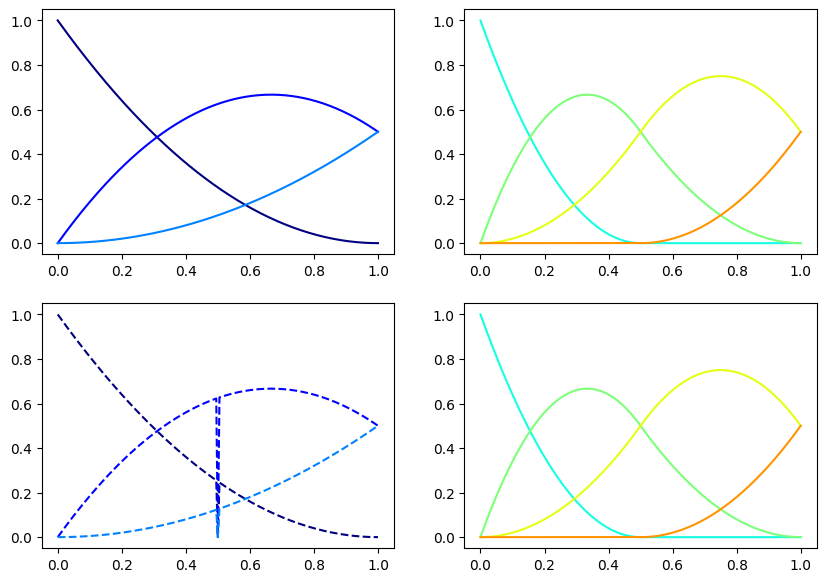

In [15]:
# now let's do the case near the left boundary (and right boundary will be same but reversed)?
# N_H = [1 - 2*xi + xi^2,
#        2*xi - 1.5*xi^2,
#        0.5*xi^2]
# left fine elem
# N_h = [1 - 4*xi + 4*xi^2,
#        4*xi - 6*xi^2,
#        2*xi^2]

# restriction for this part, N_H = R * N_lh
N_H_poly = np.array([[1.0, -2.0, 1.0], [0.0, 2.0, -1.5], [0.0, 0.0, 0.5]])
N_lh_poly = np.array([[1.0, -4.0, 4.0], [0.0, 4.0, -6.0], [0.0, 0.0, 2.0]])
# transposed cause see x above recovered in first row like that
P_left_bndry_basis = np.linalg.solve(N_lh_poly.T, N_H_poly.T).T
print(f"{P_left_bndry_basis=}")

# then restriction for right half
N_rh_poly = np.array([[2.0, -4.0, 2.0], [-1.5, 6.0, -4.0], [0.5, -2.0, 2.0]])
P_right_bndry_basis = np.linalg.solve(N_rh_poly.T, N_H_poly.T).T
print(f"{P_right_bndry_basis=}")

# becomes full restriction matrix from four fine basis to three coarse basis funcs
R_bndry = np.array([
    [1.0, 0.5, 0.0, 0.0],
    [0.0, 0.5, 0.75, 0.25],
    [0.0, 0.0, 0.25, 0.75],
])


# construct bases now of this boundary element now
p = 2
ncoarse = p+1
nfine = 2*ncoarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, nfine+ncoarse))
xi = np.linspace(0.0, 1.0, 201)
N_H = np.array([(1.0 - xi)**2, 2*xi*(1-xi) + 0.5 * xi**2, 0.5*xi**2])
N_Lh = np.array([(1.0 - 2*xi)**2, 4*xi*(1-2*xi) + 2*xi**2, 2*xi**2])
N_Lh[:,100:] = 0.0
xif = 2*xi-1
N_Rh = np.array([0.5*(1-xif)**2, 0.5*(1-xif)**2 + 2*xif*(1-xif) + 0.5*xif**2, 0.5*xif**2])
N_Rh[:, :101] = 0.0

N_h = np.zeros((4,N_Lh.shape[1]))
N_h[:3] += N_Lh
N_h[1:] += N_Rh


N_H_v2 = np.dot(R_bndry, N_h)

for i in range(4):
    N_h[i,100] = 0.5*(N_h[i,99] + N_h[i,101])

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
for i in range(3):
    ax[0,0].plot(xi, N_H[i], color=colors[i])
    ax[1,0].plot(xi, N_H_v2[i], '--', color=colors[i])
for i in range(4):
    ax[0,1].plot(xi, N_h[i], color=colors[i+3])
    ax[1,1].plot(xi, N_h[i], color=colors[i+3])
plt.show()


R=array([[1.  , 0.5 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.5 , 0.75, 0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.25, 0.75, 0.75, 0.25, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.25, 0.75, 0.75, 0.25, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 0.75, 0.5 , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  ]])


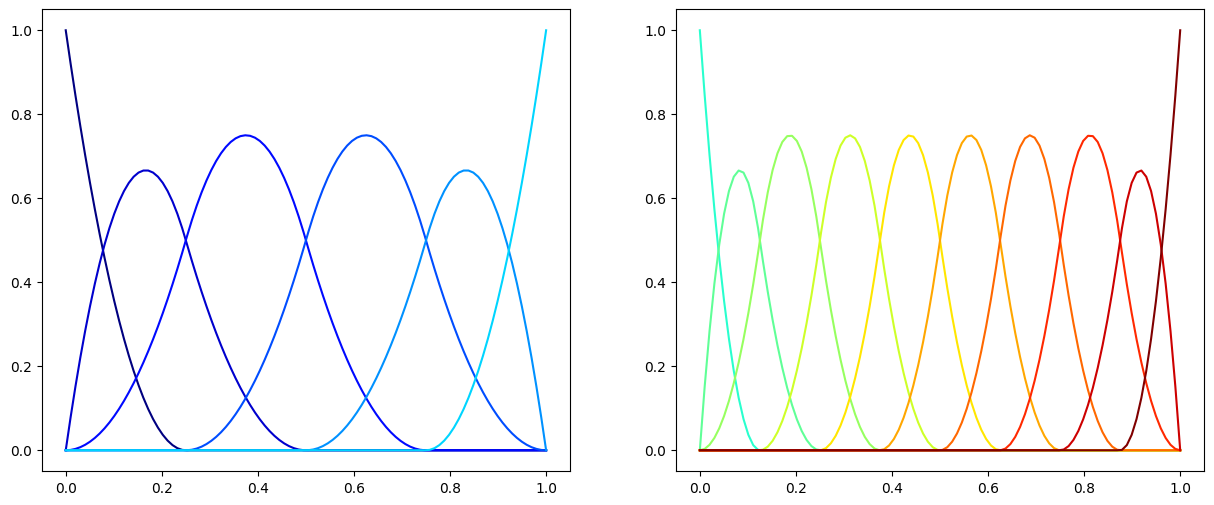

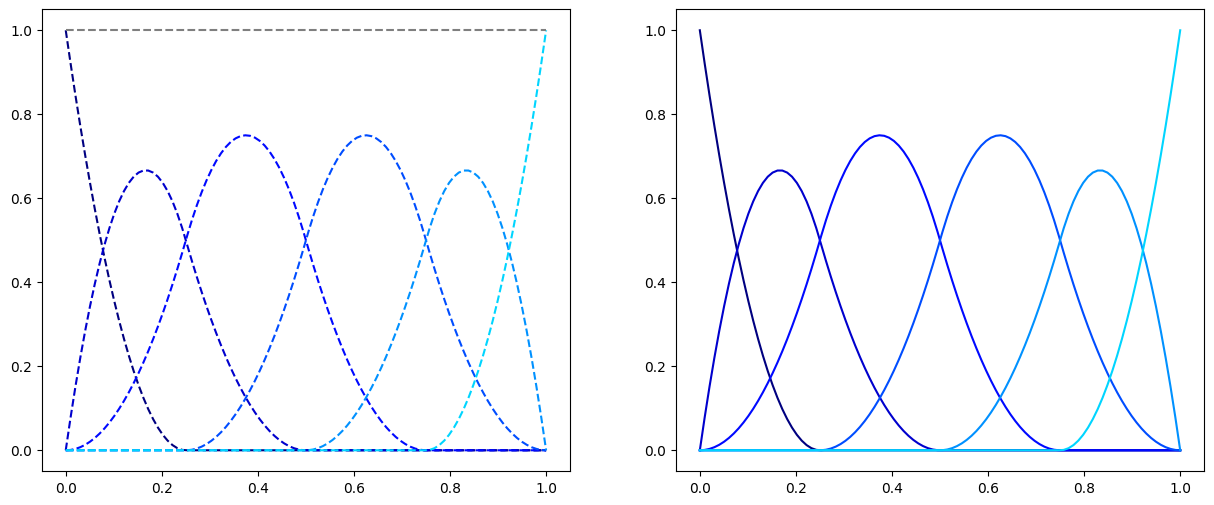

In [16]:
# now let's try the reconstruction for the whole basis for some nxe => nxe/2?
# the restriction is basically exact for IGA 2nd order.. as the coarser basis is a subset, while finer basis cannot be exactly represented
# from coarse basis

def build_basis(nxe):
    nglob = nxe+p # number of global basis functions
    colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
    knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
    def quad_bernstein(xi):
        N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
        dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
        return N, dN
    u = np.linspace(0.0, 1.0, 100)
    global_basis = np.zeros((nglob, u.shape[0]))
    elem_conn = [
        [i, i+1, i+2] for i in range(nxe) # element connectivity
    ]
    for ielem in range(nxe):
    # for ielem in range(1):
        knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
        # compute normalized coordinates in here
        xi = (u - knot1) / (knot2 - knot1)
        # zero out using mask products if xi not in 0, 1
        xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
        # compute bernstein coefficients
        B, dB = quad_bernstein(xi)

        left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
        right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

        # define optional BtoN coeffs based on el;ement position
        # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
        N1_B0 = 0.0 if left_bndry else 0.5
        N2_B0 = 1.0 if left_bndry else 0.5
        N1_B2 = 0.0 if right_bndry else 0.5
        N0_B2 = 1.0 if right_bndry else 0.5

        N0 = N2_B0 * B[0]
        N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
        N2 = N0_B2 * B[2]

        # now add into these basis functions if they exist
        local_conn = elem_conn[ielem]
        g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
        global_basis[g0] += N0 * xi_mask
        global_basis[g1] += N1 * xi_mask
        global_basis[g2] += N2 * xi_mask

    return global_basis

# construct fine and coarse bases

# nxe_f = 2
nxe_f = 8
# nxe_f = 16

p = 2
nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

fine_basis = build_basis(nxe_f)
coarse_basis = build_basis(nxe_c)

n_tot = n_fine + n_coarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, n_tot))

# re-plot fine and coarse bases
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i in range(n_coarse):
    ax[0].plot(u, coarse_basis[i], color=colors[i])
for i in range(n_fine):
    ax[1].plot(u, fine_basis[i], color=colors[i+n_coarse])


# ===============================================
# now try to reconstruct fine basis from this
# ===============================================

# restriction operator or P^T global
R = np.zeros((n_coarse, n_fine))
counts = 1e-14 * np.ones((n_coarse, n_fine))

for ielem_c in range(nxe_c):
    # left half elem
    left_felem = 2 * ielem_c
    l_mat = np.array([
        [0.75, 0.25, 0.0],
        [0.25, 0.75, 0.75],
        [0.0, 0.0, 0.25],
    ])
    if ielem_c == 0:
        l_mat[0,:2] = np.array([1.0, 0.5])
        l_mat[1,:2] = np.array([0.0, 0.5])
    if ielem_c == nxe_c - 1:
        l_mat[1, 2] = 0.5
        l_mat[2, 2] = 0.5

    # print(F"{l_mat=} {l_mat.shape=}")

    l_nz_mat = l_mat / (l_mat + 1e-14)
    R[ielem_c:(ielem_c+3), left_felem:(left_felem+3)] += l_mat
    counts[ielem_c:(ielem_c+3), left_felem:(left_felem+3)] += l_nz_mat

    # right half elem
    right_felem = 2 * ielem_c + 1
    r_mat = np.array([
        [0.25, 0.0, 0.0],
        [0.75, 0.75, 0.25],
        [0.0, 0.25, 0.75],
    ])
    if ielem_c == 0:
        r_mat[0,0] = 0.5
        r_mat[1,0] = 0.5
    if ielem_c == nxe_c - 1:
        r_mat[1, 1:] = np.array([0.5, 0.0])
        r_mat[2, 1:] = np.array([0.5, 1.0])
    r_nz_mat = r_mat / (r_mat + 1e-14)
    R[ielem_c:(ielem_c+3), right_felem:(right_felem+3)] += r_mat
    counts[ielem_c:(ielem_c+3), right_felem:(right_felem+3)] += r_nz_mat

# normalize it by weights added into each spot?
R /= counts

print(f"{R=}")

# now try to reconstruct coarse basis..
coarse_basis_v2 = np.dot(R, fine_basis)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(n_coarse):
    ax[0].plot(u, coarse_basis_v2[i], '--', color=colors[i])
ax[0].plot(u, np.ones(100), '--', color="tab:gray")
for i in range(n_coarse):
    ax[1].plot(u, coarse_basis[i], color=colors[i])

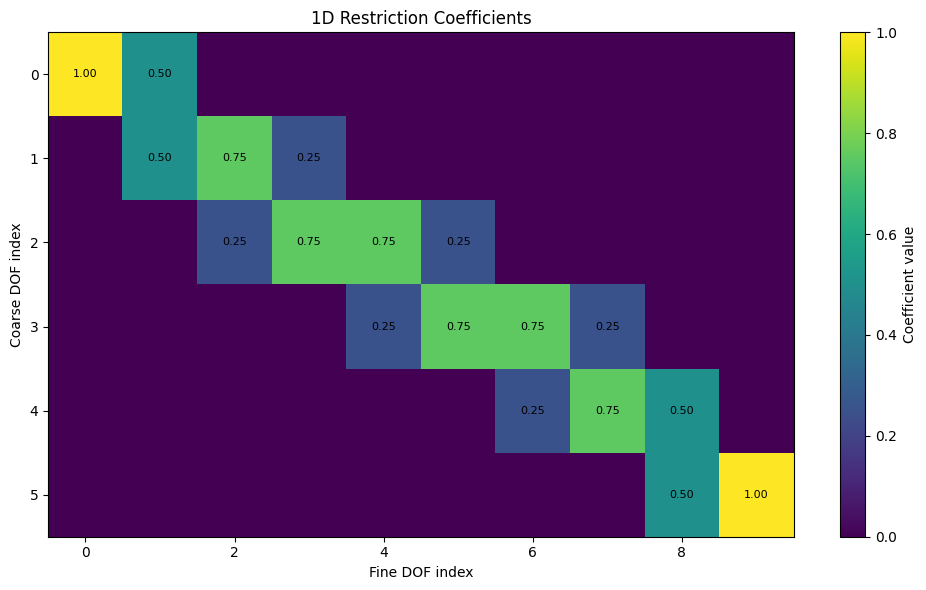

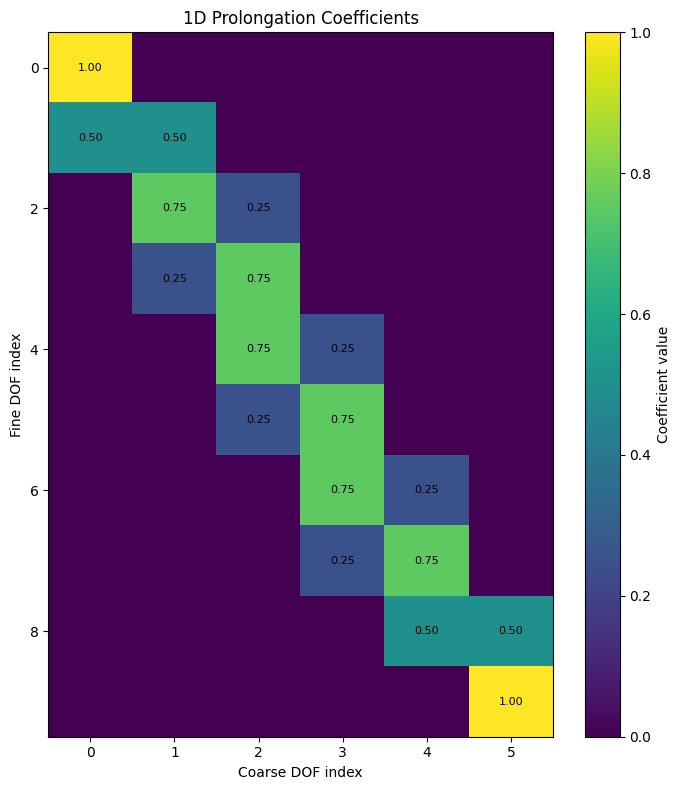

In [17]:
# plot and visualize the restriction operator (or P^T)

plt.figure(figsize=(10, 6))
plt.imshow(R, aspect="auto")
plt.colorbar(label="Coefficient value")
plt.xlabel("Fine DOF index")
plt.ylabel("Coarse DOF index")
plt.title("1D Restriction Coefficients")

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if abs(R[i, j]) > 1e-12:
            plt.text(j, i, f"{R[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# so the main stencil of coarse-fine is [0.25, 0.75, 0.75, 0.25] on interior
# and prolongation matrix wise it does have partition of unity too..


plt.figure(figsize=(7, 8))
plt.imshow(R.T, aspect="auto")
plt.colorbar(label="Coefficient value")
plt.xlabel("Coarse DOF index")
plt.ylabel("Fine DOF index")
plt.title("1D Prolongation Coefficients")

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if abs(R[i, j]) > 1e-12:
            plt.text(i, j, f"{R[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()